In [2]:
import pandas as pd

cols = (
    ["unit", "cycle", "op_setting_1", "op_setting_2", "op_setting_3"]
    + [f"sensor_{i}" for i in range(1, 22)]
)

df = pd.read_csv("../data/raw/cmapss/train_FD001.txt", sep=r"\s+", header=None)
df = df.iloc[:, :26]
df.columns = cols

print(df.shape)
print(df.head())
print(df["unit"].nunique(), "engines")
print(df.groupby("unit")["cycle"].max().describe())

(20631, 26)
   unit  cycle  op_setting_1  op_setting_2  op_setting_3  sensor_1  sensor_2  \
0     1      1       -0.0007       -0.0004         100.0    518.67    641.82   
1     1      2        0.0019       -0.0003         100.0    518.67    642.15   
2     1      3       -0.0043        0.0003         100.0    518.67    642.35   
3     1      4        0.0007        0.0000         100.0    518.67    642.35   
4     1      5       -0.0019       -0.0002         100.0    518.67    642.37   

   sensor_3  sensor_4  sensor_5  ...  sensor_12  sensor_13  sensor_14  \
0   1589.70   1400.60     14.62  ...     521.66    2388.02    8138.62   
1   1591.82   1403.14     14.62  ...     522.28    2388.07    8131.49   
2   1587.99   1404.20     14.62  ...     522.42    2388.03    8133.23   
3   1582.79   1401.87     14.62  ...     522.86    2388.08    8133.83   
4   1582.85   1406.22     14.62  ...     522.19    2388.04    8133.80   

   sensor_15  sensor_16  sensor_17  sensor_18  sensor_19  sensor_20 

In [3]:
# RUL = how many cycles are left before this engine fails
max_cycle = df.groupby("unit")["cycle"].transform("max")
df["RUL"] = max_cycle - df["cycle"]

print(df[["unit", "cycle", "RUL"]].head(10))

   unit  cycle  RUL
0     1      1  191
1     1      2  190
2     1      3  189
3     1      4  188
4     1      5  187
5     1      6  186
6     1      7  185
7     1      8  184
8     1      9  183
9     1     10  182


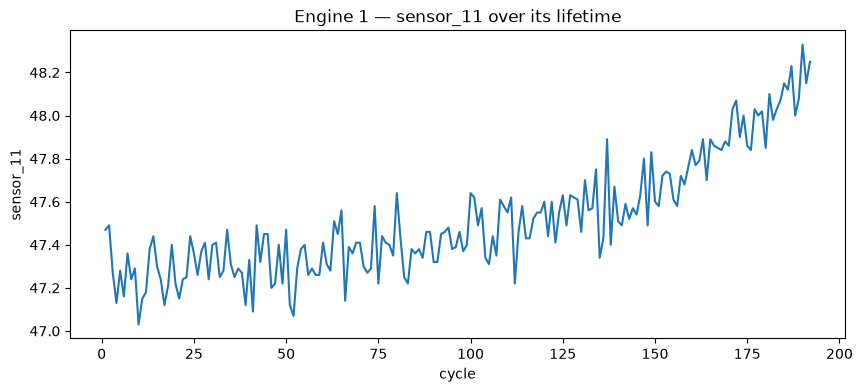

In [4]:
import matplotlib.pyplot as plt

engine_1 = df[df["unit"] == 1]

plt.figure(figsize=(10, 4))
plt.plot(engine_1["cycle"], engine_1["sensor_11"])
plt.xlabel("cycle")
plt.ylabel("sensor_11")
plt.title("Engine 1 — sensor_11 over its lifetime")
plt.show()

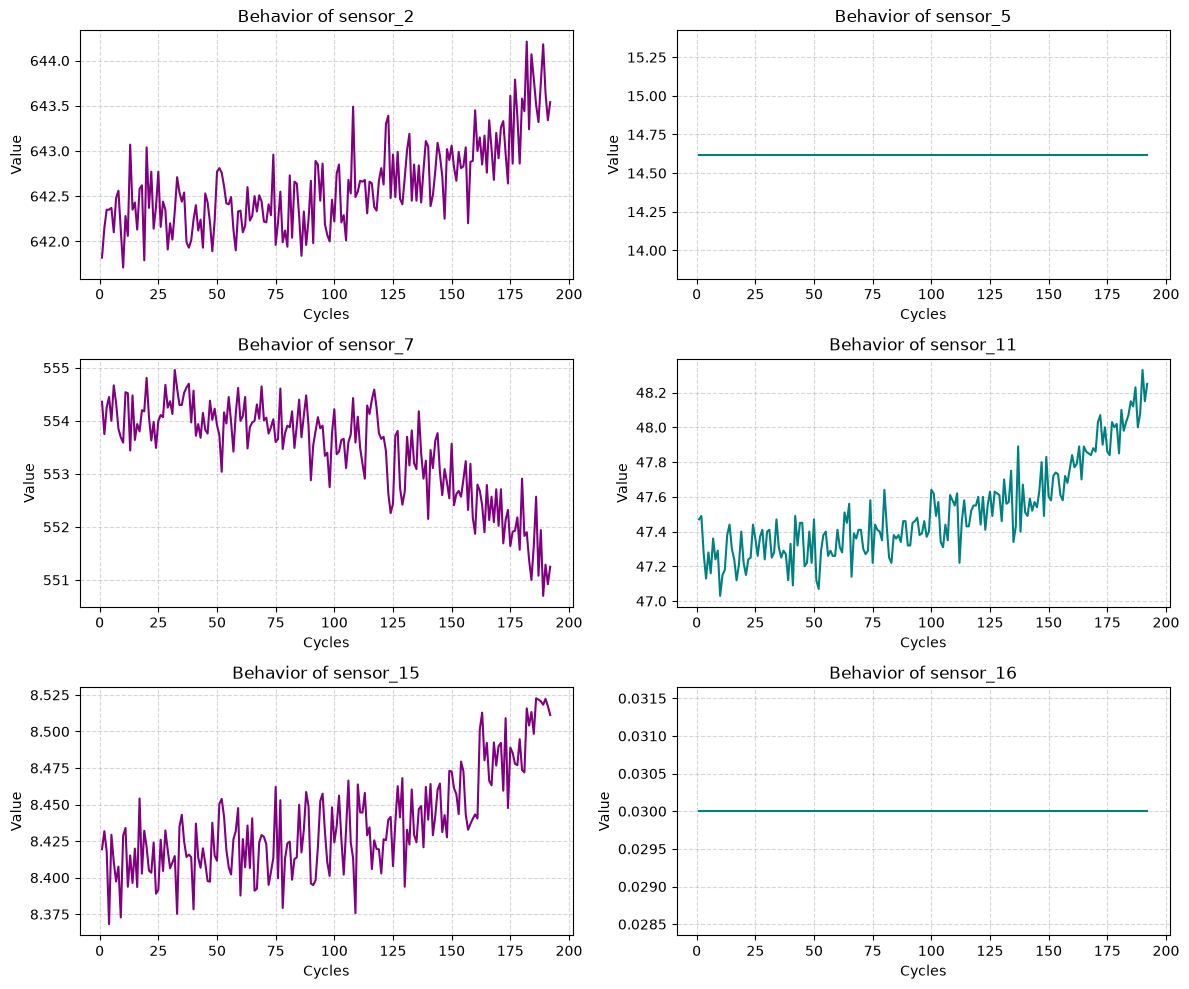

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Look at Engine 1's full history again
engine_1 = df[df["unit"] == 1]

# 2. Pick a handful of different sensors to compare
# We'll pick a mix of expected tattletales and suspected flatlines
sensors_to_check = ["sensor_2", "sensor_5", "sensor_7", "sensor_11", "sensor_15", "sensor_16"]

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for i, sensor in enumerate(sensors_to_check):
    ax = axes[i]
    ax.plot(engine_1["cycle"], engine_1[sensor], color="purple" if i%2==0 else "teal")
    ax.set_title(f"Behavior of {sensor}")
    ax.set_xlabel("Cycles")
    ax.set_ylabel("Value")
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [6]:
sensor_cols = [c for c in df.columns if c.startswith("sensor_")]
print(df[sensor_cols].std().sort_values())

sensor_1     0.000000e+00
sensor_10    0.000000e+00
sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_16    1.387812e-17
sensor_5     1.776400e-15
sensor_6     1.388985e-03
sensor_15    3.750504e-02
sensor_8     7.098548e-02
sensor_13    7.191892e-02
sensor_21    1.082509e-01
sensor_20    1.807464e-01
sensor_11    2.670874e-01
sensor_2     5.000533e-01
sensor_12    7.375534e-01
sensor_7     8.850923e-01
sensor_17    1.548763e+00
sensor_3     6.131150e+00
sensor_4     9.000605e+00
sensor_14    1.907618e+01
sensor_9     2.208288e+01
dtype: float64


In [7]:
flat_sensors = ["sensor_1", "sensor_5", "sensor_6", "sensor_10", "sensor_16", "sensor_18", "sensor_19"]

In [8]:
df = df.drop(columns=flat_sensors)
op_setting_cols = ["op_setting_1", "op_setting_2", "op_setting_3"]

sensor_cols = [c for c in df.columns if c.startswith("sensor_")]
print(f"{len(sensor_cols)} sensors remaining:", sensor_cols)

14 sensors remaining: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [9]:
print(df["op_setting_3"].std())

0.0


In [10]:
df = df.drop(columns=["op_setting_3"])

In [11]:
window = 5

for s in sensor_cols:
    df[f"{s}_roll_mean"] = df.groupby("unit")[s].transform(lambda x: x.rolling(window, min_periods=1).mean())
    df[f"{s}_roll_std"]  = df.groupby("unit")[s].transform(lambda x: x.rolling(window, min_periods=1).std())
    df[f"{s}_rate"]      = df.groupby("unit")[s].transform(lambda x: x.diff(window))

df[[f"{s}_rate", "sensor_9"]].fillna(0, inplace=False)  # just a peek, not modifying yet
print(df.shape)
print(df.columns.tolist())

(20631, 61)
['unit', 'cycle', 'op_setting_1', 'op_setting_2', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'RUL', 'sensor_2_roll_mean', 'sensor_2_roll_std', 'sensor_2_rate', 'sensor_3_roll_mean', 'sensor_3_roll_std', 'sensor_3_rate', 'sensor_4_roll_mean', 'sensor_4_roll_std', 'sensor_4_rate', 'sensor_7_roll_mean', 'sensor_7_roll_std', 'sensor_7_rate', 'sensor_8_roll_mean', 'sensor_8_roll_std', 'sensor_8_rate', 'sensor_9_roll_mean', 'sensor_9_roll_std', 'sensor_9_rate', 'sensor_11_roll_mean', 'sensor_11_roll_std', 'sensor_11_rate', 'sensor_12_roll_mean', 'sensor_12_roll_std', 'sensor_12_rate', 'sensor_13_roll_mean', 'sensor_13_roll_std', 'sensor_13_rate', 'sensor_14_roll_mean', 'sensor_14_roll_std', 'sensor_14_rate', 'sensor_15_roll_mean', 'sensor_15_roll_std', 'sensor_15_rate', 'sensor_17_roll_mean', 'sensor_17_roll_std', 'sensor_17_rate', 'sensor_20_roll_m

In [12]:
# 1. Fill NaNs from the rate features
rate_cols = [c for c in df.columns if c.endswith("_rate")]
df[rate_cols] = df[rate_cols].fillna(0)

# 2. Cap RUL at 125 (standard C-MAPSS practice)
df["RUL"] = df["RUL"].clip(upper=125)

# 3. Split by unit — 80 engines train, 20 engines test
import numpy as np
units = df["unit"].unique()
np.random.seed(42)
test_units = np.random.choice(units, size=20, replace=False)

train_df = df[~df["unit"].isin(test_units)]
test_df  = df[df["unit"].isin(test_units)]

print(train_df.shape, test_df.shape)

(16561, 61) (4070, 61)


In [16]:
import sys
sys.path.append("..")

from src.turbine.evaluate import rmse, phm08_score

# Features = everything except identifiers and the target
drop_cols = ["unit", "cycle", "RUL"]
feature_cols = [c for c in df.columns if c not in drop_cols]

X_train, y_train = train_df[feature_cols], train_df["RUL"]
X_test, y_test   = test_df[feature_cols], test_df["RUL"]

model = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)
model.fit(X_train, y_train)

preds = model.predict(X_test)
# Get just the last row of each test engine — that's the standard evaluation point
last_cycle_test = test_df.loc[test_df.groupby("unit")["cycle"].idxmax()]

X_last = last_cycle_test[feature_cols]
y_last = last_cycle_test["RUL"]
preds_last = model.predict(X_last)

print("RMSE (final cycle only):", rmse(y_last, preds_last))
print("PHM08 score (final cycle only):", phm08_score(y_last, preds_last))

RMSE (final cycle only): 3.86462451836561
PHM08 score (final cycle only): 7.920933804631661


In [17]:
# Load the real held-out test set
test_raw = pd.read_csv("../data/raw/cmapss/test_FD001.txt", sep=r"\s+", header=None)
test_raw = test_raw.iloc[:, :26]
test_raw.columns = cols

# Load the true RUL values — one per engine, in engine order
true_rul = pd.read_csv("../data/raw/cmapss/RUL_FD001.txt", header=None)[0].values

print(test_raw.shape, len(true_rul))

(13096, 26) 100


In [18]:
def engineer_features(raw_df, window=5):
    d = raw_df.copy()

    # same flat sensors dropped from training
    flat_sensors = ["sensor_1", "sensor_5", "sensor_6", "sensor_10", "sensor_16", "sensor_18", "sensor_19"]
    d = d.drop(columns=flat_sensors + ["op_setting_3"])

    sensor_cols = [c for c in d.columns if c.startswith("sensor_")]

    for s in sensor_cols:
        d[f"{s}_roll_mean"] = d.groupby("unit")[s].transform(lambda x: x.rolling(window, min_periods=1).mean())
        d[f"{s}_roll_std"]  = d.groupby("unit")[s].transform(lambda x: x.rolling(window, min_periods=1).std())
        d[f"{s}_rate"]      = d.groupby("unit")[s].transform(lambda x: x.diff(window))

    rate_cols = [c for c in d.columns if c.endswith("_rate")]
    d[rate_cols] = d[rate_cols].fillna(0)

    return d

test_featured = engineer_features(test_raw)
print(test_featured.shape)

(13096, 60)


In [19]:
# Get the last row of each test engine — the truncation point
last_rows = test_featured.loc[test_featured.groupby("unit")["cycle"].idxmax()]

# Make sure engines are in order 1, 2, 3... so predictions line up with true_rul
last_rows = last_rows.sort_values("unit")

X_real_test = last_rows[feature_cols]
preds_real = model.predict(X_real_test)

print("RMSE (real test set):", rmse(true_rul, preds_real))
print("PHM08 score (real test set):", phm08_score(true_rul, preds_real))

RMSE (real test set): 18.660624504843355
PHM08 score (real test set): 928.1066603336209


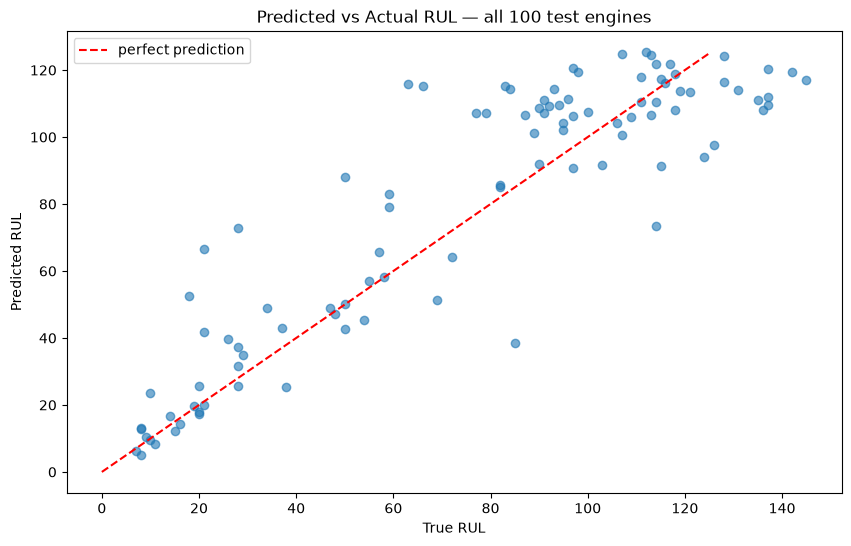

    unit  true_RUL    pred_RUL      error
78    79        63  115.814453  52.814453
26    27        66  115.239128  49.239128
36    37        21   66.564911  45.564911
17    18        28   72.698639  44.698639
71    72        50   88.182419  38.182419
40    41        18   52.521618  34.521618
14    15        83  115.324158  32.324158
15    16        84  114.411827  30.411827
66    67        77  107.310562  30.310562
49    50        79  107.182991  28.182991


In [20]:
import matplotlib.pyplot as plt
import pandas as pd

results = pd.DataFrame({
    "unit": last_rows["unit"].values,
    "true_RUL": true_rul,
    "pred_RUL": preds_real,
})
results["error"] = results["pred_RUL"] - results["true_RUL"]  # positive = late (dangerous), negative = early (safe)

plt.figure(figsize=(10, 6))
plt.scatter(results["true_RUL"], results["pred_RUL"], alpha=0.6)
plt.plot([0, 125], [0, 125], "r--", label="perfect prediction")
plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("Predicted vs Actual RUL — all 100 test engines")
plt.legend()
plt.show()

print(results.sort_values("error", ascending=False).head(10))  # worst late predictions

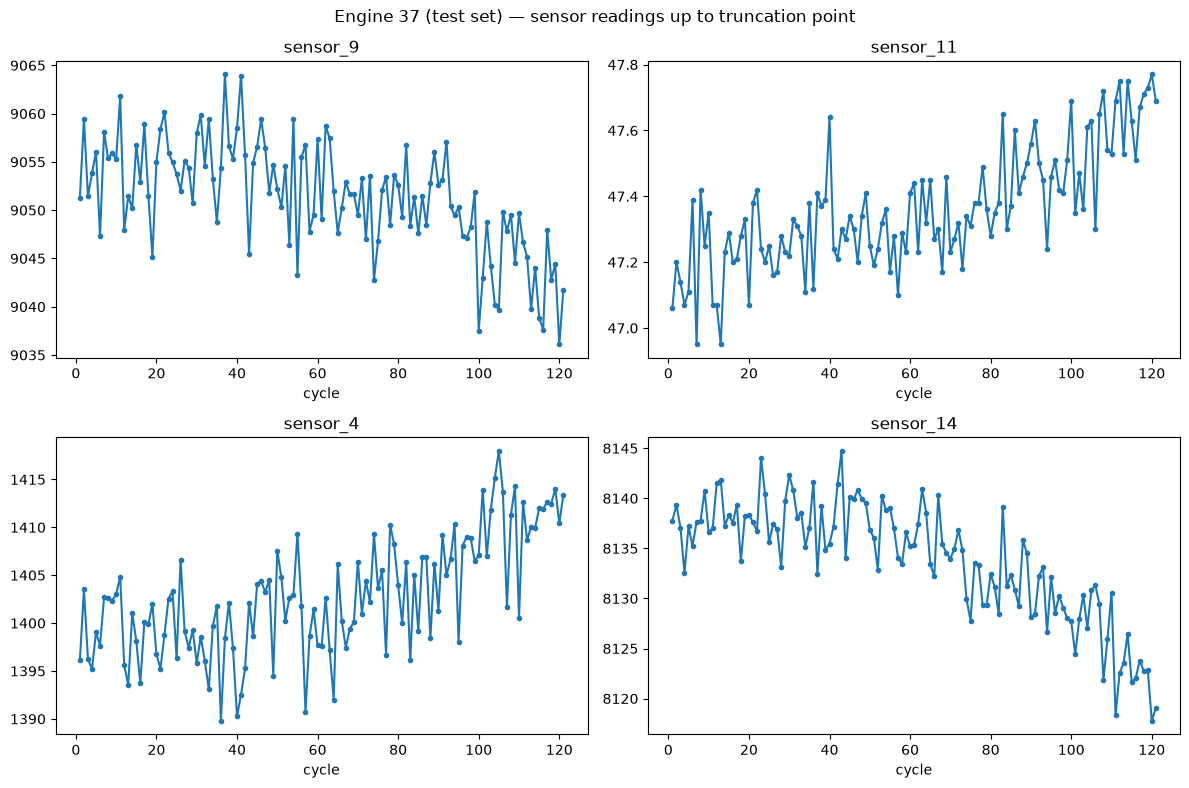

Engine 37 test data goes up to cycle: 121
True RUL at that point: 21


In [21]:
import matplotlib.pyplot as plt

engine_37_train_history = df[df["unit"] == 37]  # full life, from training file (for comparison)
engine_37_test = test_raw[test_raw["unit"] == 37]  # truncated version, what the model actually saw

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sensors_to_check = ["sensor_9", "sensor_11", "sensor_4", "sensor_14"]

for ax, s in zip(axes.flat, sensors_to_check):
    ax.plot(engine_37_test["cycle"], engine_37_test[s], marker="o", markersize=3)
    ax.set_title(s)
    ax.set_xlabel("cycle")

plt.suptitle("Engine 37 (test set) — sensor readings up to truncation point")
plt.tight_layout()
plt.show()

print("Engine 37 test data goes up to cycle:", engine_37_test["cycle"].max())
print("True RUL at that point:", 21)

In [22]:
# Compare engine 37's sensor_11 level at cycle 121 against OTHER engines at similar RUL=21
similar_rul = df[(df["RUL"] >= 15) & (df["RUL"] <= 27)]
print("sensor_11 at RUL~21, all engines:")
print(similar_rul["sensor_11"].describe())
print()
print("Engine 37's sensor_11 at its RUL=21 point:", engine_37_test["sensor_11"].iloc[-1])

sensor_11 at RUL~21, all engines:
count    1300.000000
mean       47.882815
std         0.137959
min        47.430000
25%        47.790000
50%        47.890000
75%        47.980000
max        48.270000
Name: sensor_11, dtype: float64

Engine 37's sensor_11 at its RUL=21 point: 47.69


In [23]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor

cols = (
    ["unit", "cycle", "op_setting_1", "op_setting_2", "op_setting_3"]
    + [f"sensor_{i}" for i in range(1, 22)]
)

def engineer_features(raw_df, window=5):
    d = raw_df.copy()
    flat_sensors = ["sensor_1", "sensor_5", "sensor_6", "sensor_10", "sensor_16", "sensor_18", "sensor_19"]
    d = d.drop(columns=flat_sensors + ["op_setting_3"])
    sensor_cols = [c for c in d.columns if c.startswith("sensor_")]

    for s in sensor_cols:
        d[f"{s}_roll_mean"] = d.groupby("unit")[s].transform(lambda x: x.rolling(window, min_periods=1).mean())
        d[f"{s}_roll_std"]  = d.groupby("unit")[s].transform(lambda x: x.rolling(window, min_periods=1).std())
        d[f"{s}_rate"]      = d.groupby("unit")[s].transform(lambda x: x.diff(window))
        baseline = d.groupby("unit")[s].transform(lambda x: x.iloc[:10].mean())
        d[f"{s}_baseline_drift"] = d[s] - baseline

    rate_cols = [c for c in d.columns if c.endswith("_rate")]
    d[rate_cols] = d[rate_cols].fillna(0)
    return d

# --- 1. Rebuild the training table from raw, fresh ---
raw_train = pd.read_csv("../data/raw/cmapss/train_FD001.txt", sep=r"\s+", header=None)
raw_train = raw_train.iloc[:, :26]
raw_train.columns = cols

df = engineer_features(raw_train)

max_cycle = df.groupby("unit")["cycle"].transform("max")
df["RUL"] = (max_cycle - df["cycle"]).clip(upper=125)

# --- 2. Same train/test split as before (same seed = same 20 held-out engines) ---
units = df["unit"].unique()
np.random.seed(42)
test_units = np.random.choice(units, size=20, replace=False)
train_df = df[~df["unit"].isin(test_units)]

# --- 3. Train ---
drop_cols = ["unit", "cycle", "RUL"]
feature_cols = [c for c in df.columns if c not in drop_cols]

X_train, y_train = train_df[feature_cols], train_df["RUL"]

model = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)

# --- 4. Build the REAL test set the same way ---
test_raw = pd.read_csv("../data/raw/cmapss/test_FD001.txt", sep=r"\s+", header=None)
test_raw = test_raw.iloc[:, :26]
test_raw.columns = cols
true_rul = pd.read_csv("../data/raw/cmapss/RUL_FD001.txt", header=None)[0].values

test_featured = engineer_features(test_raw)
last_rows = test_featured.loc[test_featured.groupby("unit")["cycle"].idxmax()].sort_values("unit")

X_real_test = last_rows[feature_cols]
preds_real = model.predict(X_real_test)

print("RMSE (real test set):", rmse(true_rul, preds_real))
print("PHM08 score (real test set):", phm08_score(true_rul, preds_real))

RMSE (real test set): 14.288241870745686
PHM08 score (real test set): 313.9300013056974


In [24]:
engine_37_result = pd.DataFrame({
    "unit": last_rows["unit"].values,
    "true_RUL": true_rul,
    "pred_RUL": preds_real,
})
print(engine_37_result[engine_37_result["unit"] == 37])

    unit  true_RUL   pred_RUL
36    37        21  30.420107


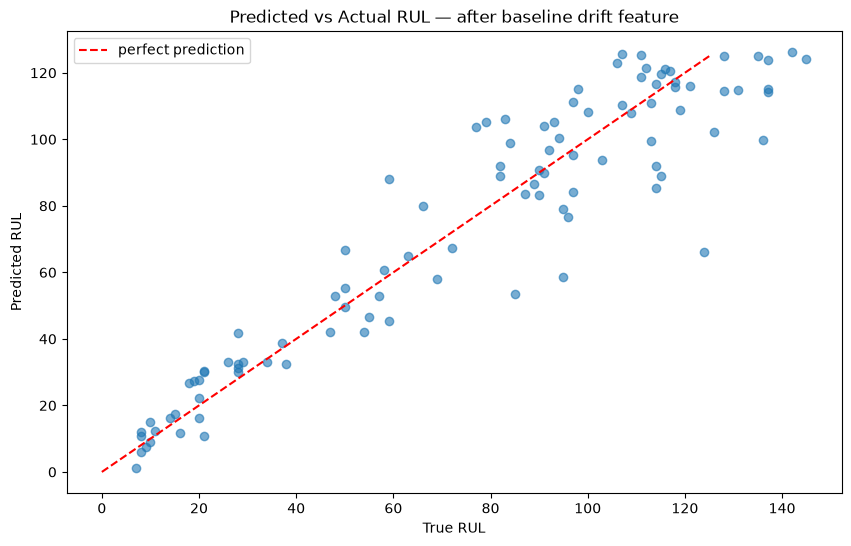

In [25]:
plt.figure(figsize=(10, 6))
plt.scatter(engine_37_result["true_RUL"], engine_37_result["pred_RUL"], alpha=0.6)
plt.plot([0, 125], [0, 125], "r--", label="perfect prediction")
plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("Predicted vs Actual RUL — after baseline drift feature")
plt.legend()
plt.show()

In [26]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor

cols = (
    ["unit", "cycle", "op_setting_1", "op_setting_2", "op_setting_3"]
    + [f"sensor_{i}" for i in range(1, 22)]
)

def engineer_features(raw_df, window=5, long_window=20):
    d = raw_df.copy()
    flat_sensors = ["sensor_1", "sensor_5", "sensor_6", "sensor_10", "sensor_16", "sensor_18", "sensor_19"]
    d = d.drop(columns=flat_sensors + ["op_setting_3"])
    sensor_cols = [c for c in d.columns if c.startswith("sensor_")]

    for s in sensor_cols:
        roll_mean = d.groupby("unit")[s].transform(lambda x: x.rolling(window, min_periods=1).mean())
        roll_std  = d.groupby("unit")[s].transform(lambda x: x.rolling(window, min_periods=1).std())
        roll_std_long = d.groupby("unit")[s].transform(lambda x: x.rolling(long_window, min_periods=1).std())
        roll_max  = d.groupby("unit")[s].transform(lambda x: x.rolling(window, min_periods=1).max())
        roll_min  = d.groupby("unit")[s].transform(lambda x: x.rolling(window, min_periods=1).min())

        d[f"{s}_roll_mean"] = roll_mean
        d[f"{s}_roll_std"]  = roll_std
        d[f"{s}_rate"]      = d.groupby("unit")[s].transform(lambda x: x.diff(window))

        baseline = d.groupby("unit")[s].transform(lambda x: x.iloc[:10].mean())
        d[f"{s}_baseline_drift"] = d[s] - baseline

        # NEW: volatility & range features
        d[f"{s}_coef_var"] = roll_std / (roll_mean.replace(0, np.nan))
        d[f"{s}_vol_growth"] = roll_std - roll_std_long
        d[f"{s}_roll_range"] = roll_max - roll_min

    rate_cols = [c for c in d.columns if c.endswith("_rate")]
    d[rate_cols] = d[rate_cols].fillna(0)
    coef_var_cols = [c for c in d.columns if c.endswith("_coef_var")]
    d[coef_var_cols] = d[coef_var_cols].fillna(0)

    # Spool ratio — correct mapping: sensor_8 = physical fan speed, sensor_9 = physical core speed
    d["spool_ratio"] = d["sensor_8"] / d["sensor_9"]

    return d

# --- 1. Rebuild the training table from raw, fresh ---
raw_train = pd.read_csv("../data/raw/cmapss/train_FD001.txt", sep=r"\s+", header=None)
raw_train = raw_train.iloc[:, :26]
raw_train.columns = cols

df = engineer_features(raw_train)

max_cycle = df.groupby("unit")["cycle"].transform("max")
df["RUL"] = (max_cycle - df["cycle"]).clip(upper=125)

# --- 2. Same train/test split as before (same seed = same 20 held-out engines) ---
units = df["unit"].unique()
np.random.seed(42)
test_units = np.random.choice(units, size=20, replace=False)
train_df = df[~df["unit"].isin(test_units)]

# --- 3. Train ---
drop_cols = ["unit", "cycle", "RUL"]
feature_cols = [c for c in df.columns if c not in drop_cols]

X_train, y_train = train_df[feature_cols], train_df["RUL"]

model = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)

# --- 4. Build the REAL test set the same way ---
test_raw = pd.read_csv("../data/raw/cmapss/test_FD001.txt", sep=r"\s+", header=None)
test_raw = test_raw.iloc[:, :26]
test_raw.columns = cols
true_rul = pd.read_csv("../data/raw/cmapss/RUL_FD001.txt", header=None)[0].values

test_featured = engineer_features(test_raw)
last_rows = test_featured.loc[test_featured.groupby("unit")["cycle"].idxmax()].sort_values("unit")

X_real_test = last_rows[feature_cols]
preds_real = model.predict(X_real_test)

print("RMSE (real test set):", rmse(true_rul, preds_real))
print("PHM08 score (real test set):", phm08_score(true_rul, preds_real))

C:\Users\USER\AppData\Local\Temp\ipykernel_19772\3610484634.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d["spool_ratio"] = d["sensor_8"] / d["sensor_9"]
C:\Users\USER\AppData\Local\Temp\ipykernel_19772\3610484634.py:53: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["RUL"] = (max_cycle - df["cycle"]).clip(upper=125)


RMSE (real test set): 14.186803300356702
PHM08 score (real test set): 300.10981270811976


C:\Users\USER\AppData\Local\Temp\ipykernel_19772\3610484634.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d["spool_ratio"] = d["sensor_8"] / d["sensor_9"]


                      feature  importance
30         sensor_4_roll_mean    0.204192
61   sensor_11_baseline_drift    0.152536
58        sensor_11_roll_mean    0.130566
33    sensor_4_baseline_drift    0.069441
86        sensor_15_roll_mean    0.052067
16         sensor_2_roll_mean    0.048444
107       sensor_21_roll_mean    0.040952
68   sensor_12_baseline_drift    0.039084
23         sensor_3_roll_mean    0.025843
54    sensor_9_baseline_drift    0.025020
40    sensor_7_baseline_drift    0.023674
89   sensor_15_baseline_drift    0.021602
103  sensor_20_baseline_drift    0.015080
93        sensor_17_roll_mean    0.012902
82   sensor_14_baseline_drift    0.012809
47    sensor_8_baseline_drift    0.012362
110  sensor_21_baseline_drift    0.009607
75   sensor_13_baseline_drift    0.007607
100       sensor_20_roll_mean    0.006011
37         sensor_7_roll_mean    0.005142


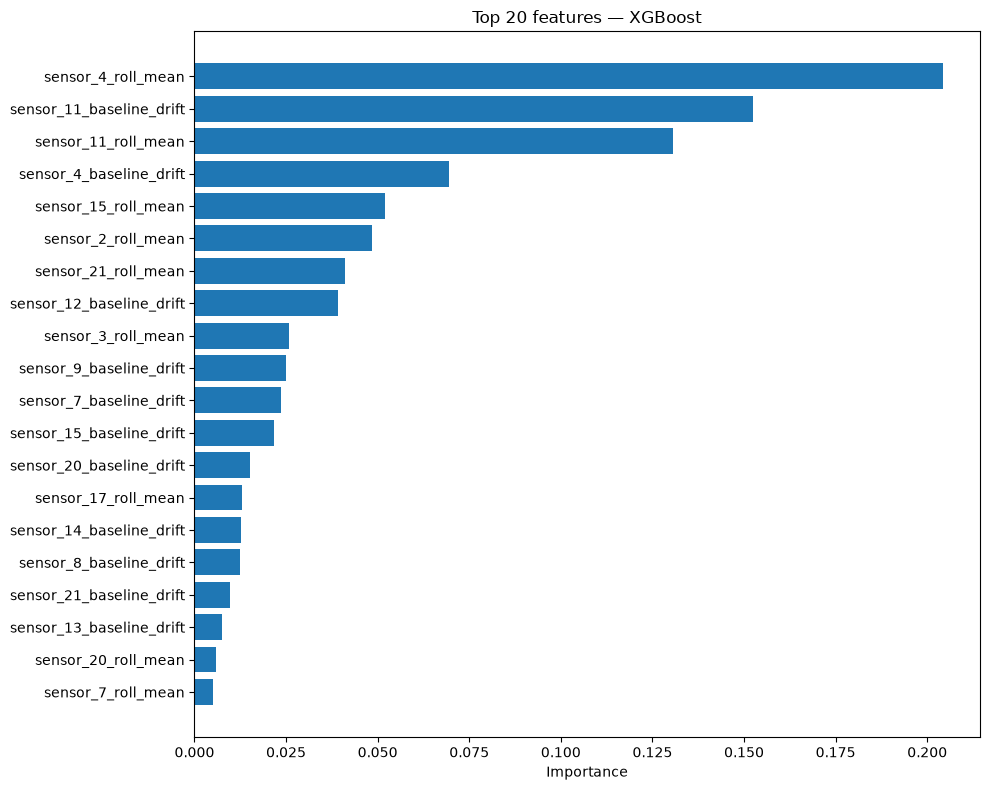

In [27]:
import pandas as pd

importances = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print(importances.head(20))

plt.figure(figsize=(10, 8))
plt.barh(importances["feature"].head(20)[::-1], importances["importance"].head(20)[::-1])
plt.xlabel("Importance")
plt.title("Top 20 features — XGBoost")
plt.tight_layout()
plt.show()

In [28]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor

cols = (
    ["unit", "cycle", "op_setting_1", "op_setting_2", "op_setting_3"]
    + [f"sensor_{i}" for i in range(1, 22)]
)

def engineer_features(raw_df, window=5):
    d = raw_df.copy()
    flat_sensors = ["sensor_1", "sensor_5", "sensor_6", "sensor_10", "sensor_16", "sensor_18", "sensor_19"]
    d = d.drop(columns=flat_sensors + ["op_setting_3"])
    sensor_cols = [c for c in d.columns if c.startswith("sensor_")]

    new_cols = {}
    for s in sensor_cols:
        roll_mean = d.groupby("unit")[s].transform(lambda x: x.rolling(window, min_periods=1).mean())
        baseline = d.groupby("unit")[s].transform(lambda x: x.iloc[:10].mean())

        new_cols[f"{s}_roll_mean"] = roll_mean
        new_cols[f"{s}_baseline_drift"] = d[s] - baseline

    d = pd.concat([d, pd.DataFrame(new_cols, index=d.index)], axis=1)
    return d

# --- 1. Rebuild the training table from raw, fresh ---
raw_train = pd.read_csv("../data/raw/cmapss/train_FD001.txt", sep=r"\s+", header=None)
raw_train = raw_train.iloc[:, :26]
raw_train.columns = cols

df = engineer_features(raw_train)

max_cycle = df.groupby("unit")["cycle"].transform("max")
df["RUL"] = (max_cycle - df["cycle"]).clip(upper=125)

# --- 2. Same train/test split as before (same seed = same 20 held-out engines) ---
units = df["unit"].unique()
np.random.seed(42)
test_units = np.random.choice(units, size=20, replace=False)
train_df = df[~df["unit"].isin(test_units)]

# --- 3. Train ---
drop_cols = ["unit", "cycle", "RUL"]
feature_cols = [c for c in df.columns if c not in drop_cols]

X_train, y_train = train_df[feature_cols], train_df["RUL"]

model = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)

# --- 4. Build the REAL test set the same way ---
test_raw = pd.read_csv("../data/raw/cmapss/test_FD001.txt", sep=r"\s+", header=None)
test_raw = test_raw.iloc[:, :26]
test_raw.columns = cols
true_rul = pd.read_csv("../data/raw/cmapss/RUL_FD001.txt", header=None)[0].values

test_featured = engineer_features(test_raw)
last_rows = test_featured.loc[test_featured.groupby("unit")["cycle"].idxmax()].sort_values("unit")

X_real_test = last_rows[feature_cols]
preds_real = model.predict(X_real_test)

print("RMSE (real test set):", rmse(true_rul, preds_real))
print("PHM08 score (real test set):", phm08_score(true_rul, preds_real))

RMSE (real test set): 14.14639551053591
PHM08 score (real test set): 296.7316741253186


In [29]:
from sklearn.model_selection import GroupKFold
import numpy as np

param_grid = [
    {"n_estimators": 200, "max_depth": 3, "learning_rate": 0.05},
    {"n_estimators": 200, "max_depth": 4, "learning_rate": 0.05},   # current baseline
    {"n_estimators": 200, "max_depth": 5, "learning_rate": 0.05},
    {"n_estimators": 300, "max_depth": 4, "learning_rate": 0.03},
    {"n_estimators": 400, "max_depth": 4, "learning_rate": 0.02},
]

gkf = GroupKFold(n_splits=5)
X_full = train_df[feature_cols]
y_full = train_df["RUL"]
groups = train_df["unit"]

results = []
for params in param_grid:
    fold_rmses = []
    for train_idx, val_idx in gkf.split(X_full, y_full, groups):
        m = XGBRegressor(**params, random_state=42)
        m.fit(X_full.iloc[train_idx], y_full.iloc[train_idx])
        preds = m.predict(X_full.iloc[val_idx])
        fold_rmses.append(rmse(y_full.iloc[val_idx], preds))
    avg_rmse = np.mean(fold_rmses)
    results.append({**params, "cv_rmse": avg_rmse})
    print(params, "-> CV RMSE:", round(avg_rmse, 3))

results_df = pd.DataFrame(results).sort_values("cv_rmse")
print(results_df)

{'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05} -> CV RMSE: 13.56
{'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05} -> CV RMSE: 13.368
{'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05} -> CV RMSE: 13.342
{'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.03} -> CV RMSE: 13.375
{'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.02} -> CV RMSE: 13.376
   n_estimators  max_depth  learning_rate    cv_rmse
2           200          5           0.05  13.341593
1           200          4           0.05  13.368359
3           300          4           0.03  13.374915
4           400          4           0.02  13.376204
0           200          3           0.05  13.559714


In [30]:
final_params = {"n_estimators": 200, "max_depth": 5, "learning_rate": 0.05, "random_state": 42}

final_model = XGBRegressor(**final_params)
final_model.fit(X_train, y_train)  # trained on train_df, same as before

final_preds = final_model.predict(X_real_test)

print("FINAL RMSE (real test set):", rmse(true_rul, final_preds))
print("FINAL PHM08 score (real test set):", phm08_score(true_rul, final_preds))

FINAL RMSE (real test set): 14.289298932158193
FINAL PHM08 score (real test set): 313.2816677033296


In [31]:
final_params = {"n_estimators": 200, "max_depth": 4, "learning_rate": 0.05, "random_state": 42}
final_model = XGBRegressor(**final_params)
final_model.fit(X_train, y_train)
final_preds = final_model.predict(X_real_test)

print("RMSE:", rmse(true_rul, final_preds))
print("PHM08:", phm08_score(true_rul, final_preds))

RMSE: 14.14639551053591
PHM08: 296.7316741253186


In [32]:
final_results = pd.DataFrame({
    "unit": last_rows["unit"].values,
    "true_RUL": true_rul,
    "pred_RUL": final_preds,
})
final_results["error"] = final_results["pred_RUL"] - final_results["true_RUL"]

late = final_results[final_results["error"] > 0]
print(f"{len(late)}/100 engines got a LATE (dangerous) prediction")
print(f"Worst late error: {late['error'].max():.1f} cycles")
print(late.sort_values('error', ascending=False).head(5))

51/100 engines got a LATE (dangerous) prediction
Worst late error: 25.8 cycles
    unit  true_RUL    pred_RUL      error
97    98        59   84.752121  25.752121
49    50        79  103.909309  24.909309
14    15        83  107.097351  24.097351
66    67        77   99.576332  22.576332
1      2        98  119.231247  21.231247


In [33]:
for shift in [0, 5, 10, 15, 20]:
    shifted_preds = final_preds - shift
    print(f"shift={shift}: RMSE={rmse(true_rul, shifted_preds):.2f}  PHM08={phm08_score(true_rul, shifted_preds):.1f}")

shift=0: RMSE=14.15  PHM08=296.7
shift=5: RMSE=15.49  PHM08=351.1
shift=10: RMSE=18.17  PHM08=496.9
shift=15: RMSE=21.68  PHM08=746.4
shift=20: RMSE=25.69  PHM08=1131.1


In [34]:
# Only pull down predictions that are ALREADY signaling "getting close to failure" —
# leave healthy-engine predictions alone, since padding those only hurts.
for threshold, shift in [(60, 5), (60, 10), (40, 10), (40, 15)]:
    adjusted = final_preds.copy()
    mask = adjusted < threshold
    adjusted[mask] = adjusted[mask] - shift
    print(f"threshold={threshold}, shift={shift}: RMSE={rmse(true_rul, adjusted):.2f}  PHM08={phm08_score(true_rul, adjusted):.1f}")

threshold=60, shift=5: RMSE=14.70  PHM08=313.4
threshold=60, shift=10: RMSE=15.85  PHM08=355.0
threshold=40, shift=10: RMSE=14.84  PHM08=311.0
threshold=40, shift=15: RMSE=15.85  PHM08=338.6


In [35]:
# --- FD003: same pipeline, separate dataset ---

raw_train_003 = pd.read_csv("../data/raw/cmapss/train_FD003.txt", sep=r"\s+", header=None)
raw_train_003 = raw_train_003.iloc[:, :26]
raw_train_003.columns = cols

df_003 = engineer_features(raw_train_003)
max_cycle_003 = df_003.groupby("unit")["cycle"].transform("max")
df_003["RUL"] = (max_cycle_003 - df_003["cycle"]).clip(upper=125)

# same split logic — by unit, same seed for consistency
units_003 = df_003["unit"].unique()
np.random.seed(42)
test_units_003 = np.random.choice(units_003, size=20, replace=False)
train_df_003 = df_003[~df_003["unit"].isin(test_units_003)]

feature_cols_003 = [c for c in df_003.columns if c not in ["unit", "cycle", "RUL"]]
X_train_003, y_train_003 = train_df_003[feature_cols_003], train_df_003["RUL"]

model_003 = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
model_003.fit(X_train_003, y_train_003)

# real held-out test set
raw_test_003 = pd.read_csv("../data/raw/cmapss/test_FD003.txt", sep=r"\s+", header=None)
raw_test_003 = raw_test_003.iloc[:, :26]
raw_test_003.columns = cols
true_rul_003 = pd.read_csv("../data/raw/cmapss/RUL_FD003.txt", header=None)[0].values

test_featured_003 = engineer_features(raw_test_003)
last_rows_003 = test_featured_003.loc[test_featured_003.groupby("unit")["cycle"].idxmax()].sort_values("unit")
X_real_test_003 = last_rows_003[feature_cols_003]
preds_003 = model_003.predict(X_real_test_003)

print("FD003 RMSE:", rmse(true_rul_003, preds_003))
print("FD003 PHM08:", phm08_score(true_rul_003, preds_003))

FD003 RMSE: 16.935714016923725
FD003 PHM08: 568.0876175814161


In [36]:
fd003_results = pd.DataFrame({
    "unit": last_rows_003["unit"].values,
    "true_RUL": true_rul_003,
    "pred_RUL": preds_003,
})
fd003_results["error"] = fd003_results["pred_RUL"] - fd003_results["true_RUL"]

print("Worst LATE predictions (dangerous):")
print(fd003_results.sort_values("error", ascending=False).head(10))
print()
print(f"{(fd003_results['error'] > 0).sum()}/100 engines got a late prediction")

Worst LATE predictions (dangerous):
    unit  true_RUL    pred_RUL      error
88    89        41   83.516762  42.516762
15    16        56   97.912003  41.912003
26    27        88  124.451714  36.451714
53    54        87  123.054993  36.054993
90    91        81  116.307693  35.307693
33    34        65  100.152954  35.152954
84    85        56   90.113846  34.113846
18    19        85  114.717438  29.717438
1      2        51   80.159210  29.159210
50    51        78  107.003265  29.003265

57/100 engines got a late prediction


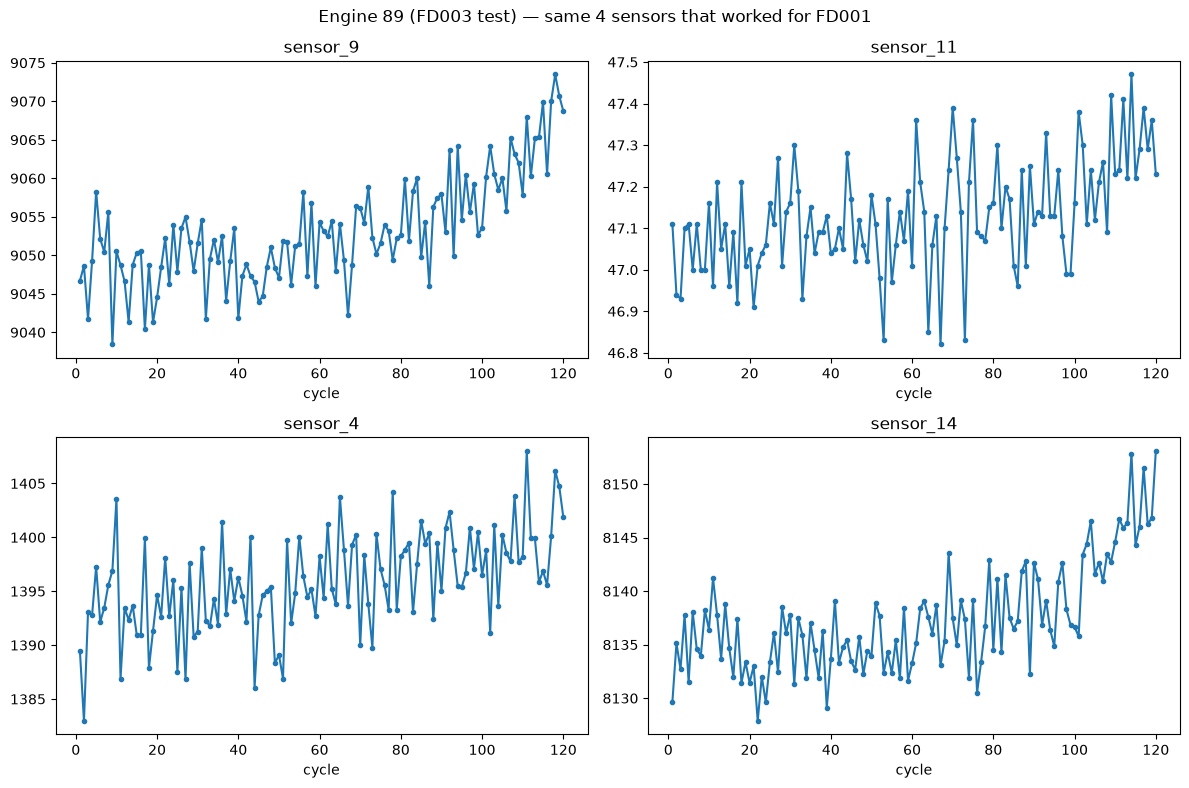

Engine 89 truncation cycle: 120
True RUL at that point: 41


In [37]:
engine_89_test = raw_test_003[raw_test_003["unit"] == 89]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sensors_to_check = ["sensor_9", "sensor_11", "sensor_4", "sensor_14"]

for ax, s in zip(axes.flat, sensors_to_check):
    ax.plot(engine_89_test["cycle"], engine_89_test[s], marker="o", markersize=3)
    ax.set_title(s)
    ax.set_xlabel("cycle")

plt.suptitle("Engine 89 (FD003 test) — same 4 sensors that worked for FD001")
plt.tight_layout()
plt.show()

print("Engine 89 truncation cycle:", engine_89_test["cycle"].max())
print("True RUL at that point:", 41)

In [38]:
def engineer_features_v2(raw_df, window=5):
    d = raw_df.copy()
    flat_sensors = ["sensor_1", "sensor_5", "sensor_6", "sensor_10", "sensor_16", "sensor_18", "sensor_19"]
    d = d.drop(columns=flat_sensors + ["op_setting_3"])
    sensor_cols = [c for c in d.columns if c.startswith("sensor_")]

    new_cols = {}
    for s in sensor_cols:
        roll_mean = d.groupby("unit")[s].transform(lambda x: x.rolling(window, min_periods=1).mean())
        baseline = d.groupby("unit")[s].transform(lambda x: x.iloc[:10].mean())
        drift = d[s] - baseline

        new_cols[f"{s}_roll_mean"] = roll_mean
        new_cols[f"{s}_baseline_drift"] = drift
        new_cols[f"{s}_abs_drift"] = drift.abs()   # NEW: magnitude, direction-agnostic

    d = pd.concat([d, pd.DataFrame(new_cols, index=d.index)], axis=1)
    return d

# Rebuild FD003 with the new function
df_003_v2 = engineer_features_v2(raw_train_003)
max_cycle_003 = df_003_v2.groupby("unit")["cycle"].transform("max")
df_003_v2["RUL"] = (max_cycle_003 - df_003_v2["cycle"]).clip(upper=125)

train_df_003_v2 = df_003_v2[~df_003_v2["unit"].isin(test_units_003)]
feature_cols_003_v2 = [c for c in df_003_v2.columns if c not in ["unit", "cycle", "RUL"]]

model_003_v2 = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
model_003_v2.fit(train_df_003_v2[feature_cols_003_v2], train_df_003_v2["RUL"])

test_featured_003_v2 = engineer_features_v2(raw_test_003)
last_rows_003_v2 = test_featured_003_v2.loc[test_featured_003_v2.groupby("unit")["cycle"].idxmax()].sort_values("unit")
preds_003_v2 = model_003_v2.predict(last_rows_003_v2[feature_cols_003_v2])

print("FD003 RMSE (with abs drift):", rmse(true_rul_003, preds_003_v2))
print("FD003 PHM08 (with abs drift):", phm08_score(true_rul_003, preds_003_v2))

FD003 RMSE (with abs drift): 16.895077401580757
FD003 PHM08 (with abs drift): 589.6612064937448


In [39]:
# Combine FD001 + FD003 training engines (avoid unit-number collisions between datasets)
raw_train_001_v2 = raw_train.copy()  # your original FD001 train data
raw_train_001_v2["unit"] = raw_train_001_v2["unit"] + 1000  # offset to keep IDs unique

combined_raw_train = pd.concat([raw_train_001_v2, raw_train_003], ignore_index=True)

df_combined = engineer_features_v2(combined_raw_train)
max_cycle_combined = df_combined.groupby("unit")["cycle"].transform("max")
df_combined["RUL"] = (max_cycle_combined - df_combined["cycle"]).clip(upper=125)

# Train on ALL of combined (no held-out split needed here — FD003's real test set is still untouched)
feature_cols_combined = [c for c in df_combined.columns if c not in ["unit", "cycle", "RUL"]]

model_combined = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
model_combined.fit(df_combined[feature_cols_combined], df_combined["RUL"])

# Evaluate on FD003's real held-out test set — same one as always, never touched
test_featured_003_v2 = engineer_features_v2(raw_test_003)
last_rows_003_v3 = test_featured_003_v2.loc[test_featured_003_v2.groupby("unit")["cycle"].idxmax()].sort_values("unit")
preds_combined = model_combined.predict(last_rows_003_v3[feature_cols_combined])

print("FD003 RMSE (trained on FD001+FD003 combined):", rmse(true_rul_003, preds_combined))
print("FD003 PHM08 (trained on FD001+FD003 combined):", phm08_score(true_rul_003, preds_combined))

FD003 RMSE (trained on FD001+FD003 combined): 16.959038962956285
FD003 PHM08 (trained on FD001+FD003 combined): 562.8289567980421


In [40]:
importances_003 = pd.DataFrame({
    "feature": feature_cols_003,
    "importance": model_003.feature_importances_
}).sort_values("importance", ascending=False)

print(importances_003.head(15))

                     feature  importance
29  sensor_11_baseline_drift    0.332587
38       sensor_17_roll_mean    0.143136
21   sensor_4_baseline_drift    0.137702
28       sensor_11_roll_mean    0.126656
18        sensor_3_roll_mean    0.039713
20        sensor_4_roll_mean    0.024616
27   sensor_9_baseline_drift    0.023797
16        sensor_2_roll_mean    0.019929
31  sensor_12_baseline_drift    0.019186
17   sensor_2_baseline_drift    0.015400
35  sensor_14_baseline_drift    0.012244
23   sensor_7_baseline_drift    0.011637
26        sensor_9_roll_mean    0.010407
39  sensor_17_baseline_drift    0.008904
30       sensor_12_roll_mean    0.005990


In [41]:
def get_engine_signature(df, sensors=["sensor_9", "sensor_14", "sensor_11", "sensor_4", "sensor_17"]):
    signatures = []
    for unit_id, group in df.groupby("unit"):
        n = len(group)
        late_life = group.iloc[int(n * 0.8):]  # last 20% of that engine's life
        sig = {"unit": unit_id}
        for s in sensors:
            sig[f"{s}_signature"] = late_life[f"{s}_baseline_drift"].mean()
        signatures.append(sig)
    return pd.DataFrame(signatures)

engine_signatures = get_engine_signature(df_003_v2)  # your FD003 training data with baseline_drift already computed
print(engine_signatures.describe())

             unit  sensor_9_signature  sensor_14_signature  \
count  100.000000          100.000000           100.000000   
mean    50.500000           32.850916            24.147818   
std     29.011492           27.343634            24.712518   
min      1.000000          -16.770303           -21.315333   
25%     25.750000            7.097210             1.301676   
50%     50.500000           41.963338            33.178041   
75%     75.250000           47.558488            37.101553   
max    100.000000          100.782636            84.783727   

       sensor_11_signature  sensor_4_signature  sensor_17_signature  
count           100.000000          100.000000           100.000000  
mean              0.595302           18.746914             3.114932  
std               0.088812            2.827310             0.547804  
min               0.312973           12.459108             1.578947  
25%               0.536510           16.572871             2.784239  
50%               0.6

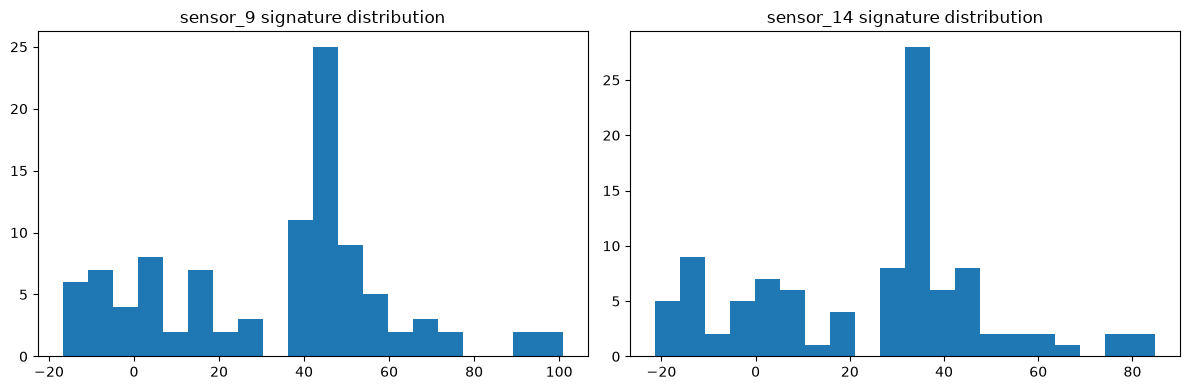

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(engine_signatures["sensor_9_signature"], bins=20)
axes[0].set_title("sensor_9 signature distribution")
axes[1].hist(engine_signatures["sensor_14_signature"], bins=20)
axes[1].set_title("sensor_14 signature distribution")
plt.tight_layout()
plt.show()

fault_cluster
0    62
1    38
Name: count, dtype: int64

               sensor_9_signature  sensor_14_signature
fault_cluster                                         
0                       51.299587            40.856632
1                        2.750452            -3.113929


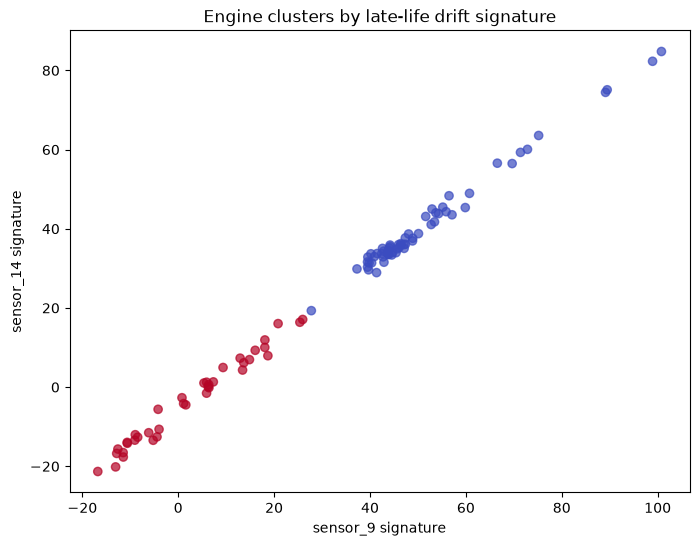

In [43]:
from sklearn.cluster import KMeans

cluster_features = ["sensor_9_signature", "sensor_14_signature"]
X_cluster = engine_signatures[cluster_features]

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
engine_signatures["fault_cluster"] = kmeans.fit_predict(X_cluster)

print(engine_signatures["fault_cluster"].value_counts())
print()
print(engine_signatures.groupby("fault_cluster")[cluster_features].mean())

plt.figure(figsize=(8, 6))
plt.scatter(engine_signatures["sensor_9_signature"], engine_signatures["sensor_14_signature"],
            c=engine_signatures["fault_cluster"], cmap="coolwarm", alpha=0.7)
plt.xlabel("sensor_9 signature")
plt.ylabel("sensor_14 signature")
plt.title("Engine clusters by late-life drift signature")
plt.show()

In [44]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_cluster, engine_signatures["fault_cluster"])
print("Silhouette score:", score)

Silhouette score: 0.7013004773453686


In [45]:
# Map each engine to its cluster, merge into the full training table
unit_to_cluster = engine_signatures.set_index("unit")["fault_cluster"]
df_003_v2["fault_cluster"] = df_003_v2["unit"].map(unit_to_cluster)

train_df_003_v3 = df_003_v2[~df_003_v2["unit"].isin(test_units_003)]
feature_cols_003_v3 = [c for c in df_003_v2.columns if c not in ["unit", "cycle", "RUL"]]

model_003_v3 = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
model_003_v3.fit(train_df_003_v3[feature_cols_003_v3], train_df_003_v3["RUL"])

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [46]:
from sklearn.linear_model import LogisticRegression

# Train a classifier: given an engine's signature (from training engines, known clusters), predict cluster
X_cluster_train = engine_signatures[cluster_features]
y_cluster_train = engine_signatures["fault_cluster"]

cluster_classifier = LogisticRegression()
cluster_classifier.fit(X_cluster_train, y_cluster_train)

# Compute the SAME signature style for test engines, using their available data (not full life)
test_signatures = get_engine_signature(test_featured_003_v2)
test_signatures["predicted_cluster"] = cluster_classifier.predict(test_signatures[cluster_features])

print(test_signatures[["unit", "predicted_cluster"]].head(10))

   unit  predicted_cluster
0     1                  1
1     2                  1
2     3                  1
3     4                  1
4     5                  1
5     6                  1
6     7                  1
7     8                  1
8     9                  1
9    10                  1


In [47]:
print(test_signatures["predicted_cluster"].value_counts())

predicted_cluster
1    84
0    16
Name: count, dtype: int64


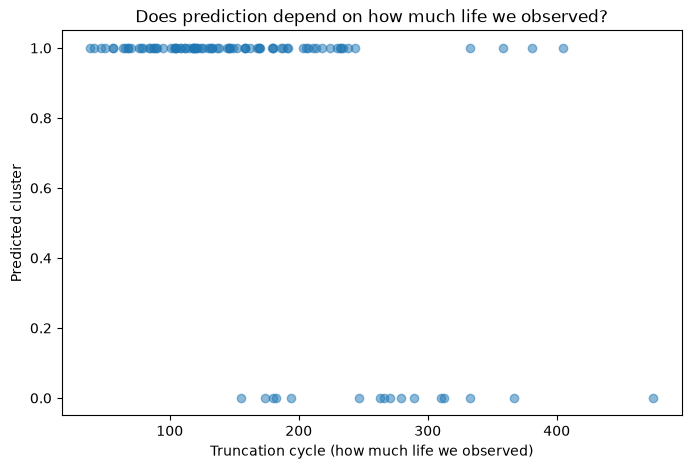

In [48]:
test_signatures["truncation_cycle"] = raw_test_003.groupby("unit")["cycle"].max().values

plt.figure(figsize=(8,5))
plt.scatter(test_signatures["truncation_cycle"], test_signatures["predicted_cluster"], alpha=0.5)
plt.xlabel("Truncation cycle (how much life we observed)")
plt.ylabel("Predicted cluster")
plt.title("Does prediction depend on how much life we observed?")
plt.show()

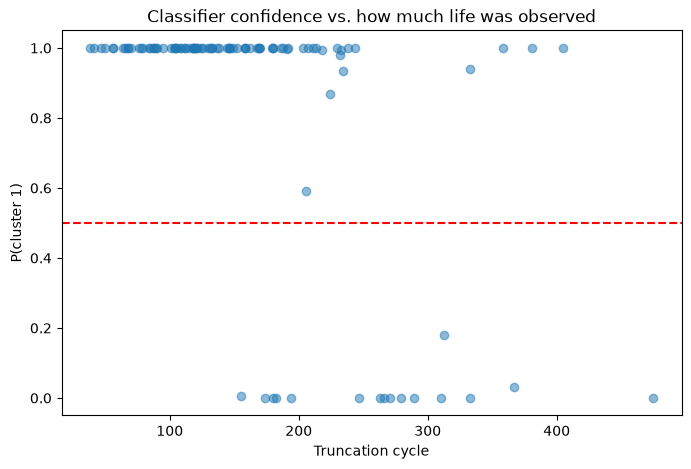

In [49]:
test_signatures["cluster_1_probability"] = cluster_classifier.predict_proba(test_signatures[cluster_features])[:, 1]

plt.figure(figsize=(8,5))
plt.scatter(test_signatures["truncation_cycle"], test_signatures["cluster_1_probability"], alpha=0.5)
plt.xlabel("Truncation cycle")
plt.ylabel("P(cluster 1)")
plt.title("Classifier confidence vs. how much life was observed")
plt.axhline(0.5, color="red", linestyle="--")
plt.show()

In [50]:
def get_engine_signature_fixed(df, sensors=["sensor_9", "sensor_14", "sensor_11", "sensor_4", "sensor_17"], n_cycles=20):
    signatures = []
    for unit_id, group in df.groupby("unit"):
        recent = group.tail(n_cycles)  # last N actual cycles, not last N% — same meaning for complete or truncated
        sig = {"unit": unit_id}
        for s in sensors:
            sig[f"{s}_signature"] = recent[f"{s}_baseline_drift"].mean()
        signatures.append(sig)
    return pd.DataFrame(signatures)

# Rebuild both training and test signatures the SAME way now
engine_signatures_v2 = get_engine_signature_fixed(df_003_v2)
test_signatures_v2 = get_engine_signature_fixed(test_featured_003_v2)

# Re-cluster training engines with the fixed signature
kmeans_v2 = KMeans(n_clusters=2, random_state=42, n_init=10)
engine_signatures_v2["fault_cluster"] = kmeans_v2.fit_predict(engine_signatures_v2[cluster_features])
print("Training cluster balance:", engine_signatures_v2["fault_cluster"].value_counts().to_dict())
print("Silhouette:", silhouette_score(engine_signatures_v2[cluster_features], engine_signatures_v2["fault_cluster"]))

# Retrain the classifier on the fixed signatures
cluster_classifier_v2 = LogisticRegression()
cluster_classifier_v2.fit(engine_signatures_v2[cluster_features], engine_signatures_v2["fault_cluster"])

# Predict on test engines using the SAME fixed-window signature
test_signatures_v2["predicted_cluster"] = cluster_classifier_v2.predict(test_signatures_v2[cluster_features])
print("Test predicted cluster balance:", test_signatures_v2["predicted_cluster"].value_counts().to_dict())

Training cluster balance: {0: 61, 1: 39}
Silhouette: 0.7220282262134183
Test predicted cluster balance: {1: 87, 0: 13}
